# ResNet-50 Training - Separated Experiments
Each preprocessing version runs in a separate cell to avoid crashes:
- **Experiment 1**: Raw
- **Experiment 2**: Unified  
- **Experiment 3**: Customized

In [2]:
%pip install torch torchvision
%pip install scikit-learn scikit-image
%pip install opencv-python
%pip install ultralytics
%pip install pandas numpy tqdm
%pip install pillow

Note: you may need to restart the kernel to use updated packages.
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scikit_image-0.26.0-cp311-cp311-win_amd64.whl.metadata (15 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached scikit_image-0.26.0-cp311-cp311-win_amd64.whl (11.9 MB)
Using cached imageio-2.37.2-py3-none-any.whl (317 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)

   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   ---------------- ----------------------- 2/5 [imageio]
   ---------------- ----------------------- 2/5 [imageio]
 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 1.4 MB/s eta 0:00:29
   - -------------------------------------- 1.0/40.2 MB 2.0 MB/s eta 0:00:20
   -- ------------------------------------- 2.4/40.2 MB 3.0 MB/s eta 0:00:13
   ---- ----------------------------------- 4.2/40.2 MB 4.9 MB/s eta 0:00:08
   -------- ------------------------------- 8.1/40.2 MB 7.3 MB/s eta 0:00:05
   ---------------- ----------------------- 16.5/40.2 MB 12.4 MB/s eta 0:00:02
   ----------------------- ---------------- 24.1/40.2 MB 15.7 MB/s eta 0:00:02
   ------------------------------- -------- 32.0/40.2 MB 18.5 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 21.3 MB/s  0:00:02
Note: you may need to 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 2.4 MB/s eta 0:00:04
   ----------- ---------------------------- 2.9/9.9 MB 4.8 MB/s eta 0:00:02
   ------------------------------ --------- 7.6/9.9 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 10.8 MB/s  0:00:01

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [tqdm]
   ------------- -------------------------- 1/3 [tqdm]
   ------------- -------------------------- 1/3 [tqdm]
   ------------- -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import os, json, gc
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

# SETUP & DEVICE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = os.path.join("..", "data")
MODEL_SAVE_DIR = "."
JSON_PATH = os.path.join(DATA_DIR, "dataset_split.json")
CATEGORIES = ['Can', 'Paper', 'Plastic Bag', 'Plastic Bottle']

print(f"Using device: {DEVICE}")
print(f"Data directory: {DATA_DIR}")
print(f"Model save directory: {MODEL_SAVE_DIR}")

# Load dataset split once
with open(JSON_PATH, 'r') as f: 
    split = json.load(f)
    
print(f"Train samples: {len(split['train'])}")
print(f"Test samples: {len(split['test'])}")

Using device: cuda
Data directory: ..\data
Model save directory: .
Train samples: 6319
Test samples: 1358


In [2]:
# DATASET CLASS AND FUNCTIONS
class WasteJSONDataset(Dataset):
    def __init__(self, root_dir, file_list, transform=None):
        self.root_dir = root_dir
        self.file_list = file_list
        self.transform = transform
        self.class_to_idx = {cat: i for i, cat in enumerate(CATEGORIES)}

    def __len__(self): 
        return len(self.file_list)

    def __getitem__(self, idx):
        rel_path = self.file_list[idx]
        img_path = os.path.join(self.root_dir, rel_path)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            image = Image.new('RGB', (512, 512), (0, 0, 0))
            
        label = self.class_to_idx[rel_path.split('/')[0]]
        if self.transform: 
            image = self.transform(image)
        return image, label

def get_dataloaders(version, batch_size=32):
    """Generate data loaders for the specified preprocessing version"""
    if version == 'raw':
        data_path = os.path.join(DATA_DIR, "Cropped")
    else:
        data_path = os.path.join(DATA_DIR, f"processed_{version}")
    
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    train_ds = WasteJSONDataset(data_path, split['train'], transform=transform)
    test_ds = WasteJSONDataset(data_path, split['test'], transform=transform)
    
    return {
        'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0),
        'test': DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    }, len(train_ds), len(test_ds)

def train_model(model, loaders, criterion, optimizer, num_epochs=5):
    """Train the model"""
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        progress_bar = tqdm(loaders['train'], desc=f'Epoch {epoch+1}/{num_epochs}')
        
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})
        
        epoch_loss = running_loss / len(loaders['train'].dataset)
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")
    
    return model

def evaluate_and_record(model, loaders, version):
    """Evaluate model and return metrics"""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loaders['test'], desc='Evaluating'):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    metrics = {
        'Model': 'ResNet-50',
        'Preprocessing': version,
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'Recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'F1-score': f1_score(all_labels, all_preds, average='macro', zero_division=0)
    }
    return metrics

def run_resnet_experiment(version):
    print(f"\n{'='*60}")
    print(f"🚀 ResNet-50 Experiment: {version.upper()}")
    print(f"{'='*60}")
    
    try:
        # Get data loaders
        loaders, train_size, test_size = get_dataloaders(version=version, batch_size=32)
        print(f"Training samples: {train_size}")
        print(f"Test samples: {test_size}")
        
        # Initialize Pretrained ResNet50
        model = models.resnet50(weights='IMAGENET1K_V2')
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 4)  # 4 waste classes
        model = model.to(DEVICE)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
        
        # Train
        print("Starting training...")
        trained_model = train_model(model, loaders, criterion, optimizer, num_epochs=5)
        
        # Save Model Weights
        save_name = f"resnet50_{version}.pth"
        save_path = os.path.join(MODEL_SAVE_DIR, save_name)
        torch.save(trained_model.state_dict(), save_path)
        print(f"✅ Model saved as {save_path}")
        
        # Evaluate and append result
        print("Evaluating model...")
        res = evaluate_and_record(trained_model, loaders, version)
        
        print(f"\n📊 Results for {version}:")
        for key, value in res.items():
            if key not in ['Model', 'Preprocessing']:
                print(f"  {key}: {value:.4f}")
        
        # Save individual result
        result_path = os.path.join(DATA_DIR, f"resnet50_{version}_results.csv")
        pd.DataFrame([res]).to_csv(result_path, index=False)
        print(f"✅ Results saved to {result_path}")
        
        return res
        
    except Exception as e:
        print(f"❌ Error processing {version}: {e}")
        return None

print("✅ Setup complete!")

✅ Setup complete!


In [3]:
# 🔥 EXPERIMENT 1: RAW
torch.cuda.empty_cache()
gc.collect()

result_raw = run_resnet_experiment('raw')

# Clear memory
torch.cuda.empty_cache()
gc.collect()
print("\n🧹 Memory cleared after RAW experiment")


🚀 ResNet-50 Experiment: RAW
Training samples: 6319
Test samples: 1358
Starting training...


Epoch 1/5: 100%|██████████| 198/198 [1:09:10<00:00, 20.96s/it, Loss=0.0435]


Epoch 1/5 - Loss: 0.2711


Epoch 2/5: 100%|██████████| 198/198 [1:06:01<00:00, 20.01s/it, Loss=0.0513]


Epoch 2/5 - Loss: 0.0510


...

Epoch 4/5 - Loss: 0.0235


Epoch 5/5: 100%|██████████| 198/198 [1:05:40<00:00, 19.90s/it, Loss=0.0137]


Epoch 5/5 - Loss: 0.0305
✅ Model saved as .\resnet50_raw.pth
Evaluating model...


Evaluating: 100%|██████████| 43/43 [04:27<00:00,  6.21s/it]



📊 Results for raw:
  Accuracy: 0.9838
  Precision: 0.9806
  Recall: 0.9773
  F1-score: 0.9789
✅ Results saved to ..\data\resnet50_raw_results.csv

🧹 Memory cleared after RAW experiment


In [4]:
# 🔥 EXPERIMENT 2: UNIFIED
torch.cuda.empty_cache()
gc.collect()

result_unified = run_resnet_experiment('unified')

# Clear memory
torch.cuda.empty_cache()
gc.collect()
print("\n🧹 Memory cleared after UNIFIED experiment")


🚀 ResNet-50 Experiment: UNIFIED
Training samples: 6319
Test samples: 1358
Starting training...


Epoch 1/5: 100%|██████████| 198/198 [56:37<00:00, 17.16s/it, Loss=0.2199] 


Epoch 1/5 - Loss: 0.5693


Epoch 2/5: 100%|██████████| 198/198 [3:01:53<00:00, 55.12s/it, Loss=0.7604]    


Epoch 2/5 - Loss: 0.1890


...

Epoch 4/5 - Loss: 0.0547


Epoch 5/5: 100%|██████████| 198/198 [55:48<00:00, 16.91s/it, Loss=0.1059]


Epoch 5/5 - Loss: 0.0298
✅ Model saved as .\resnet50_unified.pth
Evaluating model...


Evaluating: 100%|██████████| 43/43 [04:39<00:00,  6.51s/it]



📊 Results for unified:
  Accuracy: 0.9374
  Precision: 0.9255
  Recall: 0.9158
  F1-score: 0.9201
✅ Results saved to ..\data\resnet50_unified_results.csv

🧹 Memory cleared after UNIFIED experiment


In [5]:
# 🔥 EXPERIMENT 3: CUSTOMIZED
torch.cuda.empty_cache()
gc.collect()

result_customized = run_resnet_experiment('customized')

# Clear memory
torch.cuda.empty_cache()
gc.collect()
print("\n🧹 Memory cleared after CUSTOMIZED experiment")


🚀 ResNet-50 Experiment: CUSTOMIZED
Training samples: 6319
Test samples: 1358
Starting training...


Epoch 1/5: 100%|██████████| 198/198 [56:55<00:00, 17.25s/it, Loss=0.2713]


Epoch 1/5 - Loss: 0.2549


Epoch 2/5: 100%|██████████| 198/198 [58:48<00:00, 17.82s/it, Loss=0.0084]


Epoch 2/5 - Loss: 0.0791


...

Epoch 4/5 - Loss: 0.0410


Epoch 5/5: 100%|██████████| 198/198 [1:03:38<00:00, 19.29s/it, Loss=0.0129]


Epoch 5/5 - Loss: 0.0243
✅ Model saved as .\resnet50_customized.pth
Evaluating model...


Evaluating: 100%|██████████| 43/43 [04:47<00:00,  6.69s/it]



📊 Results for customized:
  Accuracy: 0.9816
  Precision: 0.9879
  Recall: 0.9874
  F1-score: 0.9876
✅ Results saved to ..\data\resnet50_customized_results.csv

🧹 Memory cleared after CUSTOMIZED experiment


In [6]:
# 📊 CONSOLIDATE ALL RESULTS
all_results = []
for result in [result_raw, result_unified, result_customized]:
    if result is not None:
        all_results.append(result)

if all_results:
    # Save consolidated results
    consolidated_path = os.path.join(DATA_DIR, "resnet50_all_results.csv")
    df_results = pd.DataFrame(all_results)
    df_results.to_csv(consolidated_path, index=False)
    
    print(f"\n✅ Consolidated results saved to {consolidated_path}")
    print(f"\n📊 FINAL RESNET-50 SUMMARY:")
    print("="*60)
    print(df_results.to_string(index=False))
    
    # Find best result
    best_idx = df_results['Accuracy'].idxmax()
    best_result = df_results.iloc[best_idx]
    print(f"\n🏆 BEST RESNET-50: {best_result['Preprocessing']} (Accuracy: {best_result['Accuracy']:.4f})")
else:
    print("❌ No results to consolidate")

print("\n🏁 ResNet-50 experiments completed!")


✅ Consolidated results saved to ..\data\resnet50_all_results.csv

📊 FINAL RESNET-50 SUMMARY:
    Model Preprocessing  Accuracy  Precision   Recall  F1-score
ResNet-50           raw  0.983800   0.980623 0.977260  0.978887
ResNet-50       unified  0.937408   0.925546 0.915804  0.920070
ResNet-50    customized  0.981591   0.987912 0.987375  0.987631

🏆 BEST RESNET-50: raw (Accuracy: 0.9838)

🏁 ResNet-50 experiments completed!


📂 Data Directory: ..\data
⚙️ Device: cuda

📊 Generating Bar Chart...


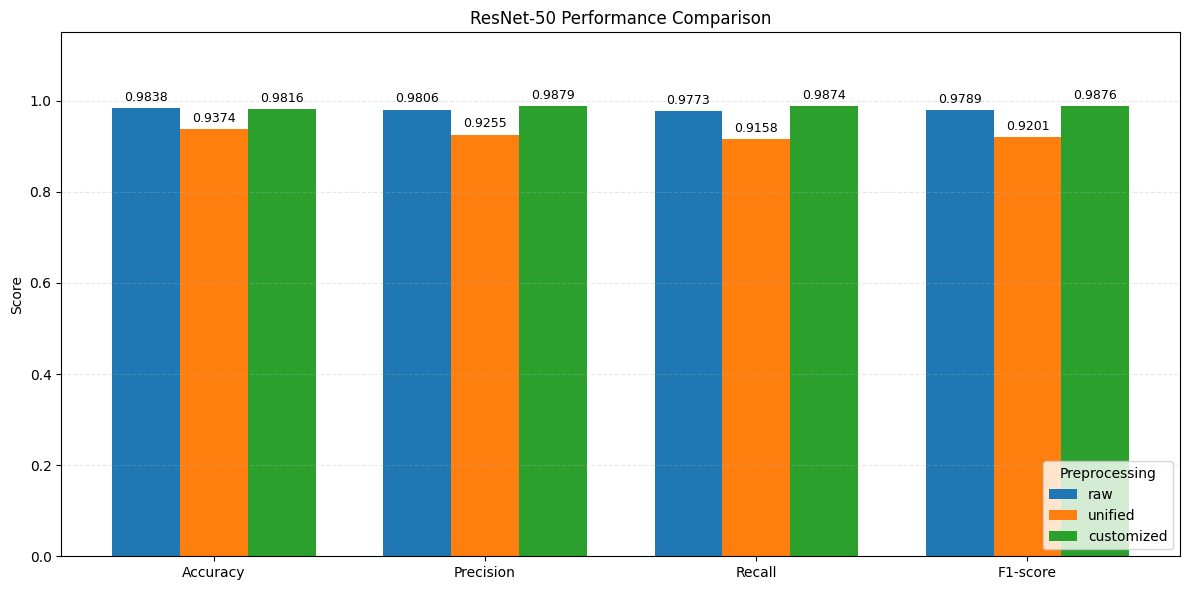


🔥 Generating Heatmap...


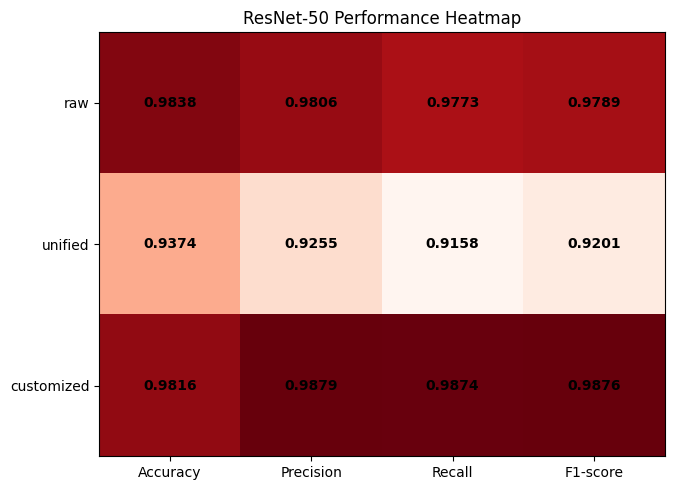


🧠 Loading 'Raw' Model for Confusion Matrix & PR Curve...


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\User\AppData\Local\Temp\ipykernel_15648\1110290491.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future r

🚀 Running inference (ResNet-50)...


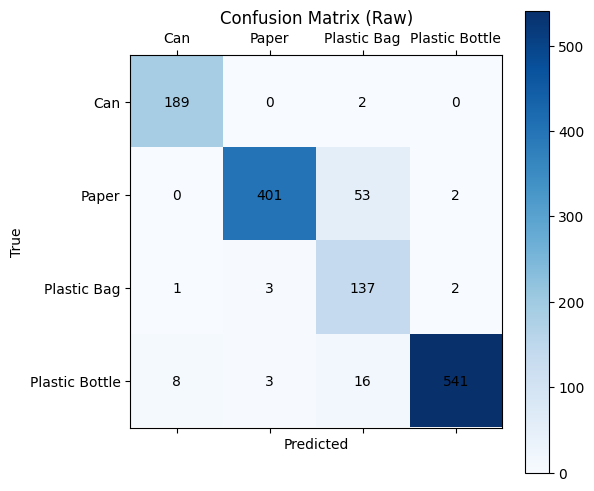

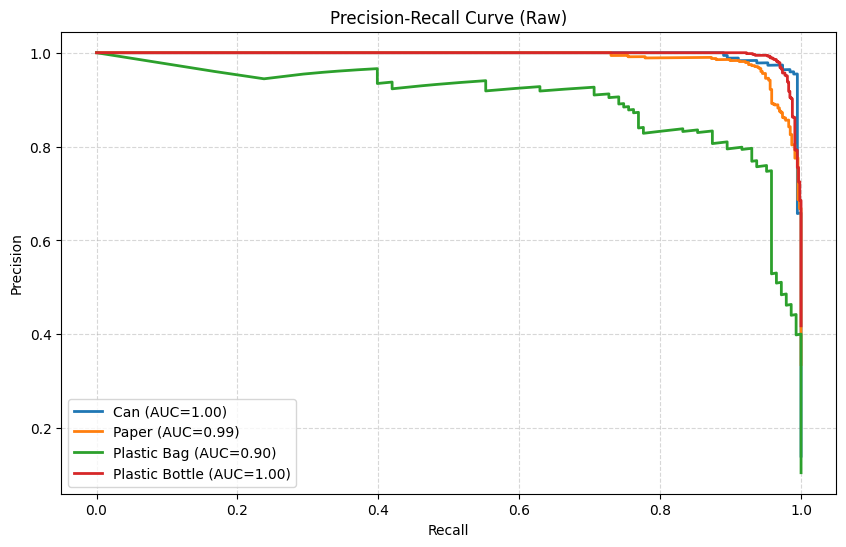


📜 Scanning notebook logs for Training Curves...


C:\Users\User\AppData\Local\Temp\ipykernel_15648\1110290491.py:217: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.set_title("Validation Accuracy"); ax2.legend(); ax2.grid(True, alpha=0.3)


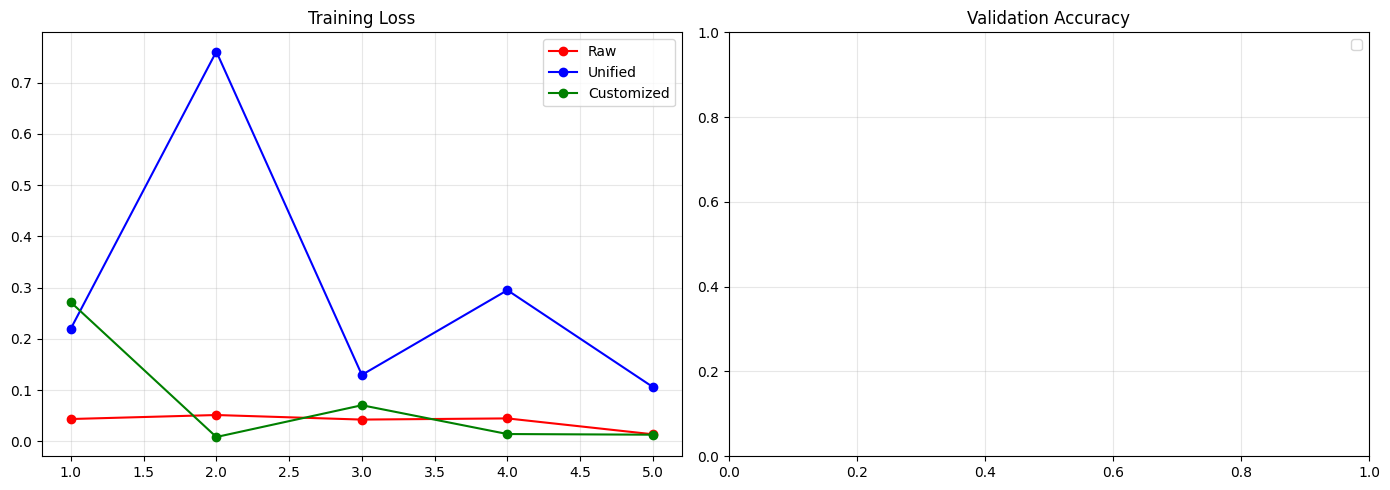

In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc
from PIL import Image

# ==========================================
# 1. SETUP PATHS & CONFIG
# ==========================================
# We look for data in the folder one level up ("../data")
DATA_DIR = os.path.join("..", "data")
IMG_DIR = os.path.join(DATA_DIR, "Cropped")
JSON_PATH = os.path.join(DATA_DIR, "dataset_split.json")
RESULTS_CSV = os.path.join(DATA_DIR, "resnet50_all_results.csv")
MODEL_PATH = os.path.join(DATA_DIR, "resnet50_raw.pth") 
NOTEBOOK_PATH = "03.3_train_resnet50.ipynb"

CATEGORIES = ['Can', 'Paper', 'Plastic Bag', 'Plastic Bottle']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"📂 Data Directory: {DATA_DIR}")
print(f"⚙️ Device: {DEVICE}")

# ==========================================
# 2. PLOT 1: METRIC COMPARISON BAR CHART
# ==========================================
if os.path.exists(RESULTS_CSV):
    print("\n📊 Generating Bar Chart...")
    df = pd.read_csv(RESULTS_CSV)
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
    preprocessing_types = df['Preprocessing'].unique()
    
    x = np.arange(len(metrics))
    width = 0.25
    fig, ax = plt.subplots(figsize=(12, 6))

    for i, prep_type in enumerate(preprocessing_types):
        row = df[df['Preprocessing'] == prep_type]
        if row.empty: continue
        values = row[metrics].values.flatten()
        offset = (i - 1) * width
        rects = ax.bar(x + offset, values, width, label=prep_type)
        ax.bar_label(rects, padding=3, fmt='%.4f', fontsize=9)

    ax.set_ylabel('Score')
    ax.set_title('ResNet-50 Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.15)
    ax.legend(title='Preprocessing', loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. PLOT 2: METRIC HEATMAP
# ==========================================
if os.path.exists(RESULTS_CSV):
    print("\n🔥 Generating Heatmap...")
    # Extract data matrix
    data_matrix = []
    for pt in preprocessing_types:
        row = df[df['Preprocessing'] == pt][metrics].values.flatten()
        data_matrix.append(row)
    data_matrix = np.array(data_matrix)

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(data_matrix, cmap="Reds") # Using Red theme for ResNet

    # Labels
    ax.set_xticks(np.arange(len(metrics)))
    ax.set_yticks(np.arange(len(preprocessing_types)))
    ax.set_xticklabels(metrics)
    ax.set_yticklabels(preprocessing_types)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    ax.set_title("ResNet-50 Performance Heatmap")

    # Add numbers
    for i in range(len(preprocessing_types)):
        for j in range(len(metrics)):
            text = ax.text(j, i, f"{data_matrix[i, j]:.4f}",
                           ha="center", va="center", color="black", fontweight="bold")
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. PLOT 3 & 4: CONFUSION MATRIX & PR CURVE (RAW MODEL)
# ==========================================
if os.path.exists(MODEL_PATH) and os.path.exists(IMG_DIR):
    print("\n🧠 Loading 'Raw' Model for Confusion Matrix & PR Curve...")
    
    # Dataset Class (Robust to Slashes)
    class WasteJSONDataset(Dataset):
        def __init__(self, root_dir, file_list, transform=None):
            self.root_dir, self.file_list, self.transform = root_dir, file_list, transform
            self.class_to_idx = {cat: i for i, cat in enumerate(CATEGORIES)}
        def __len__(self): return len(self.file_list)
        def __getitem__(self, idx):
            rel_path = self.file_list[idx]
            img_path = os.path.join(self.root_dir, rel_path)
            try:
                image = Image.open(img_path).convert("RGB")
            except:
                image = Image.new('RGB', (224, 224), (0, 0, 0)) # Fallback
            if self.transform: image = self.transform(image)
            
            # Robust Slash Handling
            clean_path = rel_path.replace("\\", "/") 
            label_str = clean_path.split("/")[0]
            if label_str not in self.class_to_idx:
                for cat in CATEGORIES:
                    if cat in rel_path: label_str = cat; break
            
            return image, self.class_to_idx[label_str]

    # Load Data & Model
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    with open(JSON_PATH, 'r') as f: test_files = json.load(f)['test']
    test_loader = DataLoader(WasteJSONDataset(IMG_DIR, test_files, transform=test_transform), batch_size=32, shuffle=False)

    # ResNet-50 Architecture
    model = models.resnet50(pretrained=False)
    # ResNet uses .fc, not .classifier
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(CATEGORIES))
    
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model = model.to(DEVICE).eval()

    # Inference
    print("🚀 Running inference (ResNet-50)...")
    y_true, y_pred, y_scores = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(DEVICE))
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_scores.extend(probs.cpu().numpy())
    y_true, y_scores = np.array(y_true), np.array(y_scores)

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 6))
    cax = ax.matshow(cm, cmap='Blues')
    fig.colorbar(cax)
    ax.set_xticks(np.arange(len(CATEGORIES)))
    ax.set_yticks(np.arange(len(CATEGORIES)))
    ax.set_xticklabels(CATEGORIES)
    ax.set_yticklabels(CATEGORIES)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Raw)')
    for i in range(len(CATEGORIES)):
        for j in range(len(CATEGORIES)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    plt.show()

    # Plot PR Curve
    plt.figure(figsize=(10, 6))
    for i, cat in enumerate(CATEGORIES):
        if np.sum(y_true == i) > 0:
            precision, recall, _ = precision_recall_curve(y_true == i, y_scores[:, i])
            pr_auc = auc(recall, precision)
            plt.plot(recall, precision, lw=2, label=f'{cat} (AUC={pr_auc:.2f})')
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve (Raw)')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.5); plt.show()

# ==========================================
# 5. PLOT 5: TRAINING CURVES (FROM LOGS)
# ==========================================
if os.path.exists(NOTEBOOK_PATH):
    print("\n📜 Scanning notebook logs for Training Curves...")
    with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f: nb = json.load(f)
    
    extracted = []
    for cell in nb['cells']:
        if 'outputs' in cell:
            for out in cell['outputs']:
                if 'text' in out:
                    for line in out['text']:
                        if "Epoch" in line and "Loss=" in line:
                            ep = int(re.search(r"Epoch (\d+)", line).group(1))
                            ls = float(re.search(r"Loss=([\d\.]+)", line).group(1))
                            extracted.append({'epoch': ep, 'loss': ls, 'val_acc': None})
                        val = re.search(r"Validation Accuracy:\s*([\d\.]+)", line)
                        if val and extracted: extracted[-1]['val_acc'] = float(val.group(1))

    if extracted:
        # Assuming 5 epochs per experiment
        datasets = {
            "Raw": extracted[0:5],
            "Unified": extracted[5:10] if len(extracted) > 5 else [],
            "Customized": extracted[10:15] if len(extracted) > 10 else []
        }
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        colors = {'Raw': 'red', 'Unified': 'blue', 'Customized': 'green'}
        
        for name, data in datasets.items():
            if not data: continue
            epochs = [d['epoch'] for d in data]
            losses = [d['loss'] for d in data]
            vals = [d['val_acc'] for d in data if d['val_acc'] is not None]
            ax1.plot(epochs, losses, marker='o', label=name, color=colors.get(name))
            if len(vals) == len(epochs): ax2.plot(epochs, vals, marker='o', label=name, color=colors.get(name))
            
        ax1.set_title("Training Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)
        ax2.set_title("Validation Accuracy"); ax2.legend(); ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()
    else:
        print("⚠️ No training logs found in notebook output.")